# Introduction to Workbench

Programming for quantum computes requires a different set of operations to build quantum programs. **Workbench** is a tool for developing algorithms for Fault-Tolerant quantum computers. This kata gives an introduction into the basics of writing quantum algorithms with Workbench.



## QPU

The QPU represents the quantum processing unit used to execute a Workbench program. It acts as the interface between your program and the quantum backend.  In particular, it manages:

* Allocating and releasing qubits
* Drawing circuit representation of the programs
* Supporting program testing and debugging by accessing the quantum simulator state directly
* Getting estimates of resources, such as number of qubits and number of magic states, necessary for running the program on a fault-tolerant quantum computer
* Processing and track low-level QPU events and instructions
* Configuring compilation pipelines

We will cover the basics of the QPU API throughout this notebook.

## QPU Initialization

At a minimum, a QPU must be instantiated with a certain number of qubits. Otherwise, there will be no quantum resources to perform computation on. Below is a basic instantiation of a QPU by specifying the `num_qubits` argument:

```python
qpu = QPU(num_qubits=3)
```

The `num_qubits` argument sets the upper limit of qubits available to the QPU. A program will not be able to allocate more qubits than have been specified at QPU instantiation.

You can learn more about the QPU in the [documentation](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/QPU-Object.html).

## Problem 1: Instantiate a QPU

**Inputs**:
1. An integer representing the number of qubits to initialize the QPU with

**Goal**:

Instantiate and return a QPU object with a upper limit of qubits equal to the input integer.

In [2]:
from test_IntroToWorkbench import problem
from psiqdk.workbench import QPU

@problem
def instantiate_qpu(num_qubits: int):
    qpu = QPU(num_qubits=num_qubits) # Instantiate the QPU here
    return qpu

Correct!


## Allocating Qubits

Now that we have defined a QPU that has an upper limit of qubits, we can allocate **Qubit Registers** over specific ranges of the qubits available to the QPU.

A qubit register is allocated with the `Qubits` class. At instantiation, we pass QPU a that manages the allocation. We can can also pass a string as an argument representing the name of the register.

The below code snippet allocates two non-overlapping registers on a five qubit QPU, one \("reg1"\) with three qubits and another (\("reg2"\)) with two qubits.

```python
qpu = QPU(num_qubits=5) # Instantiating a QPU with 5 qubits

reg1 = Qubits(3, "reg1", qpu=qpu) # Allocating a qubit named reg1 with 3 qubits
reg2 = Qubits(2, "reg2", qpu=qpu) # Allocating a qubit named reg2 with 2 qubits
```

You can learn more about Qubits in the [documentation](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Qubits-Data-Type.html).

## Problem 2: Instantiate a Qubit Register

**Inputs**:
1. A QPU object to manage allocation.
2. An integer representing the number of qubits the register should be instantiated with
3. A string representing the name of the register.

**Goal**:

Instantiate and return a Qubits object allocated on the qiven QPU, with the given number of qubits, and named with the given string.

In [3]:
from test_IntroToWorkbench import problem
from psiqdk.workbench import QPU, Qubits

@problem
def instantiate_qubits(qpu: QPU, num_qubits: int, qubit_name: str):
    qubits = Qubits(num_qubits, qubit_name, qpu) # Instantiate the Qubits object here
    return qubits

Correct!


## Quantum Gates

**Quantum Gates** are the building blocks for performing quantum computation in Workbench programs.  These are single operations that are applied to a specific set of Qubits.

Gates are applied by calling methods on a `Qubits` objects.  Since qubits are associated with a particular QPU, this adds the particular gate to the program automatically.  When we call a method on a  `Qubits` object, the gate is applied to every sub-qubit in that object as well.

Some gates require additional parameterization, such as rotation gates.  These are provided as arguments to the gate method when needed.

Below we show the application of `x`, `y` and `z` gates to `Qubits` objects of various sizes to demonstrate the application of the gate to the entire register.  We also show the application of an `rx` gate with 37 degree rotation on `reg1`.

You can learn more about gates in the [documentation](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Basic-Gates.html).

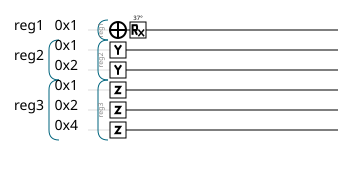

In [4]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=6)
reg1 = Qubits(1, "reg1", qpu=qpu)
reg2 = Qubits(2, "reg2", qpu=qpu)
reg3 = Qubits(3, "reg3", qpu=qpu)

reg1.x()
reg2.y()
reg3.z()

reg1.rx(37)

qpu.draw()

## Problem 3: Apply Quantum Gates

**Inputs**:
1. A `Qubits` object to apply gates to.
2. An integer value of the angle to use for rotations.

**Goal**:

Apply an `x` gate and an `rx` gate with the given integer value to the `Qubits` object.

In [5]:
from test_IntroToWorkbench import problem
from psiqdk.workbench import QPU, Qubits

@problem
def apply_gates(reg: Qubits, value: int):
    reg.x() # Apply an x gate to the qubit
    reg.rx(value) # Apply an rx gate with the given value to the qubit

Correct!


## Controlled Quantum Gates

However, singular gates without any conditions are not enough to perform quantum computation.  Often times, we need to apply a specific gate to one qubit register conditionally on the whether another qubit register is in the $|1\rangle$ state. This is done through controlled gates.

In Workbench, all gate methods on qubits can be modified with the `cond` argument.  The `cond` argument accepts a `Qubits` register. There is no specific modifier for the number of controls.  Below, we show how we can expand the number of controls simply by having registers of different sizes being passed to `cond`.

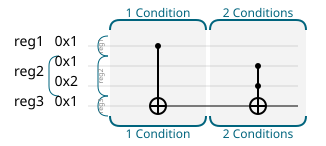

In [6]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=4)
reg1 = Qubits(1, "reg1", qpu=qpu)
reg2 = Qubits(2, "reg2", qpu=qpu)
reg3 = Qubits(1, "reg3", qpu=qpu)

qpu.label("1 Condition")
reg3.x(cond=reg1)
qpu.label("2 Conditions")
reg3.x(cond=reg2)

qpu.draw()

However, we do not have to only condition on the all $|1\rangle$ state. If we want to control a set of target qubits in a particular state we can check that a register is instead equal to a particular value.

In the example below, we condition on a two-qubit register, and show conditioning on the $|0\rangle, |1\rangle, |2\rangle$ and $|3\rangle$ states. Notice that the $|3\rangle$ state is the same as the all $|1\rangle$ case.

You can learn more about controlled gates in the [documentation](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Controlled-Gates.html).

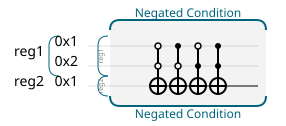

In [7]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
reg1 = Qubits(2, "reg1", qpu=qpu)
reg2 = Qubits(1, "reg2", qpu=qpu)

qpu.label("Negated Condition")
reg2.x(cond=reg1==0)
reg2.x(cond=reg1==1)
reg2.x(cond=reg1==2)
reg2.x(cond=reg1==3)

qpu.draw()

## Problem 4: Apply Controlled Quantum Gates

**Inputs**:
1. A `Qubits` object representing the first register.
2. A `Qubits` object representing the second register.

**Goal**:

Apply three controlled `x` gates:
1. `reg1` controls `reg2` on the $|1\rangle$ state.
2. `reg1` controls `reg2` on the $|0\rangle$ state.
3. `reg2` controls `reg1`  on the $|1\rangle$ state.

In [8]:
from test_IntroToWorkbench import problem

@problem
def apply_controlled_gates(reg1: Qubits, reg2: Qubits):
    reg2.x(reg1) # Apply an controlled-x gate where reg1 controls reg2 on |1>
    reg2.x(~reg1) # Apply an controlled-x gate where reg1 controls reg2 on |0>
    reg1.x(reg2) # Apply an controlled-x gate where reg2 controls reg1 on |1>

Correct!


## Drawing the Circuit

As we build quantum programs, they can become difficult to debug. One method of debugging and verifying the construction of quantum programs is by visually inspecting the circuit. Through the use of labels and boxes, this can help identify problems in quantum programs that might be difficult to analyze from observing the state vector or programmatic construction process alone.

The `QPU.draw()` method outputs the circuit to an SVG that can be displayed in a notebook.

Som utility drawing methods:
- `nop()` adds blank padding operations
- `label("name")` highlights a sections of the circuit with label `"name"`
- `label()` ends a previously started label

You can learn more about drawing circuits in the [documentation](https://docs.construct.psiquantum.com/psiqdk-workbench/howtos/Draw-Circuit.html).

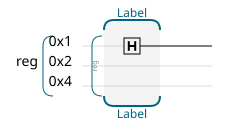

In [9]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
reg = Qubits(3, "reg", qpu=qpu)

# Starts the label in the drawing
qpu.label("Label")

# Adds padding
reg[0].had()

# Ends the label
qpu.label()

qpu.draw()

## Accessing Particular Qubits

As quantum programs get larger and more complicated, having the granularity of individual `Qubits` objects can become necessary. Workbench provides the ability to directly index and slice qubits.

In order to access a particular qubit in a register, we can use indexing, similar to accessing a particular element in an array in Python:

```python
q = Qubits(10, "q", qpu)

q[0] # Accesses the first qubit in the register
q[3] # Accesses the fourth qubit in the register
q[-1] # Accesses the last qubit in the register
```

Also similar to Python arrays, we can use slicing to capture ranges of `Qubits`. If we have a `Qubits` object `reg`, we can access a range of elements using `reg[start:stop:step]`. This produces a subarray of qubits in a new `Qubits` object beginning at index `start`, stopping at `stop-1`, but only selecting the item at every index `(index - start) % step == 0`.

Below, we show an example of different combinations of indexing and slicing arrays. Notice that we apply a gate directly the output of the indexing or slicing operation.  This is possible because each slice and index operation results in a new `Qubits` object that can be operated the same way as the initial instantiation.

You can learn more about accessing qubits in the [documentation](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Qubits-Data-Type.html).

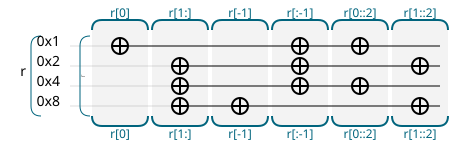

In [10]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=4)
r = Qubits(4, "r", qpu=qpu)

qpu.label("r[0]")   # First qubit
r[0].x()

qpu.label("r[1:]")  # All qubits except the first one
r[1:].x()

qpu.label("r[-1]")  # Last qubit
r[-1].x()

qpu.label("r[:-1]") # All qubits except the last one
r[:-1].x()

qpu.label("r[0::2]")  # Even qubits
r[0::2].x()

qpu.label("r[1::2]")  # Odd qubits
r[1::2].x()

qpu.draw()

## Problem 5: Indexing and Slicing

**Inputs**:
1. A `Qubits` register.

**Goal**:

Apply 2 different `x` gates to different ranges:
* Apply an `x` gate to the second qubit in the register with a single operation.
* Apply an `x` gate to every even-indexed qubit except the zeroth with a single operation.

You may assume that the `Qubits` register will always be large enough to satisfy these conditions.

In [11]:
from test_IntroToWorkbench import problem
from psiqdk.workbench import QPU, Qubits

@problem
def indexing_and_slicing(reg: Qubits):
    reg[1].x() # Apply an x gate to the second qubit in the register with a single operation
    reg[2::2].x() # Apply an x gate to every even qubits except the first with a single operation

Correct!


## Combining Qubits

Beyond the granularity of accessing individual qubits, combining multiple ranges of `Qubits` objects can be useful. For instance, an algorithm can to combine two registers to act a single control. As such, Workbench also provides a native operator to combine two registers.

By using the `|` or Bitwise-Or operator, we can concatenate two `Qubits` objects. The result is a single `Qubits` object that can be used the same way as the initially instantiated `Qubits` object.

```python
r1 = Qubits(1, "r1", qpu=qpu)
r2 = Qubits(1, "r2", qpu=qpu)
r3 = r1 | r2 # A concatenation of r1 and r2, giving a two qubit register.
```

This result can be directly passed to a `Qubits` constructor instead of the number of qubits in the register. This allows us to name the resulting concatenation.

```python
r1 = Qubits(1, "r1", qpu=qpu)
r2 = Qubits(1, "r2", qpu=qpu)
r3 = Qubits(r1 | r3, "r3") # A concatenation of r1 and r2, giving a two qubit register.
```

Below, we show both concatenations by applying a gate to both styles of concatenated qubit. Notice that they produce the same result, but the register is named in the second case.

You can learn more about combining qubits in the [documentation](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Qubits-Data-Type.html).

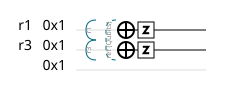

In [12]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)
r1 = Qubits(1, "r1", qpu=qpu)
r3 = Qubits(1, "r3", qpu=qpu)

concat = r1 | r3 # Concatenate two qubits
ref = Qubits(r1 | r3, "ref") # Concatenate two qubits and name the result

concat.x()
ref.z()

qpu.draw()

## Problem 6: Combining Qubits

**Inputs**:
1. A `Qubits` Register
2. A `Qubits` Register
3. A `Qubits` Register

**Goal**:

Apply three different gates to different combinations of gates:
1. Apply an `x` gate to the concatenation of the first and third registers
2. Apply an `y` gate to the concatenation of the second and third registers
3. Apply an `z` gate to the concatenation of the first, second and third registers

In [13]:
from test_IntroToWorkbench import problem
from psiqdk.workbench import QPU, Qubits

@problem
def concatenate_registers(reg1: Qubits, reg2: Qubits, reg3: Qubits):
    (reg1 | reg3).x() # Apply an x gate to the concatenation of the first and third registers
    (reg2 | reg3).y()  # Apply an y gate to the concatenation of the second and third registers
    (reg1 | reg2 | reg3).z() # Apply an z gate to the concatenation of the first, second and third registers

Correct!


## Getting State Vector Information

Workbench is not only used for building programs, it is a simulator. When using a simulator, we do not have to measure the qubits, we can directly observe the state vector. This can be an incredibly useful tool for debugging particular components of quantum programs.

There are two main ways we can access the state vector by using the QPU interface.

We can use the `print_state_vector()` method on a QPU to get the non-zero amplitudes.

We can also use the `pull_state()` method on a QPU to get the entire state vector. This is a useful tools if we need to programatically observe the amplitudes for specific states. In particular, when writing tests for Workbench programs.

We show both of these below. The indices denoting the amplitudes correspond to the bitstring representation of the state in little endian form.

You can learn more about using the state vector in the [documentation](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Testing-Debugging.html).

In [14]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=3)

reg1 = Qubits(2, "reg1", qpu)
reg2 = Qubits(1, "reg2", qpu)

reg1[0].ry(2 * 60)
reg1[1].ry(2 * 30, cond=reg1[0])
reg2.ry(-2 * 45)


print("Printed Vector")
qpu.print_state_vector()


print("\nPulled State")
print(qpu.pull_state())

Printed Vector
|reg1|reg2>
|0|0>    0.353553+0.000000j
|0|1>    -0.353553+0.000000j
|1|0>    0.530330+0.000000j
|1|1>    -0.530330+0.000000j
|3|0>    0.306186+0.000000j
|3|1>    -0.306186+0.000000j

Pulled State
[ 0.35355339+0.j  0.53033009+0.j  0.        +0.j  0.30618622+0.j
 -0.35355339+0.j -0.53033009+0.j  0.        +0.j -0.30618622+0.j]


## Problem 7: Using the State Vector

**Input**:
1. A QPU object to observe the state of.

**Goal**:

Determine information about the state vector
- Get the state vector from the QPU.
- Identify the states with the maximum amplitude.
- Return the result as a sorted list of indices.

**Examples**:
- If the state vector was `[0.707, 0, 0, 0.707]`, the function should return `[0, 3]`.
- If the state vector was `[0, 0, 1, 0]`, the function should return `[2]`.

You may assume all amplitudes are real values.

<details>
<summary><strong>Need a hint?</strong></summary>

Hint: To test whether two amplitudes are the same, use the `np.isclose` method.

Hint: To sort an array you may used `sorted(array)` to return a sorted array

</details>

In [15]:
from test_IntroToWorkbench import problem
from psiqdk.workbench import QPU, Qubits
import numpy as np

@problem
def examine_state_vector(qpu: QPU) -> list[int]:
    equal_amplitudes = []
    # Get the state vector and determine the indices with the maximum amplitude
    state_vector = qpu.pull_state()
    max_val = 0
    for ind, val in enumerate(state_vector):
        if val > max_val:
            equal_amplitudes = [ind]
            max_val = val
        elif np.isclose(val, max_val):
            equal_amplitudes.append(ind)
    return equal_amplitudes

Correct!


## Measuring Qubits

We do not apply direct measurement gates in Workbench programs, instead we use the `read()` method on a `Qubits` register.

The `read()` method returns an integer representing the measurement result in little endian format.  That is, the zeroth-index in the qubit represents the least signifcant bit in the binary representation of the integer.

Below we show applying a `read` to a particular Qubit and print the result in several different cases.

You can learn more about measurements in the [documentation](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Measurements.html).

First Register Result:  2


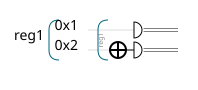

First Register Result:  1


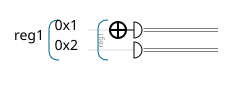

In [17]:
from psiqdk.workbench import QPU, Qubits

qpu = QPU(num_qubits=2)

reg1 = Qubits(2, "reg1", qpu=qpu)

reg1[1].x()

# res_reg is 2
res_reg = reg1.read()
print("First Register Result: ", res_reg)

qpu.draw()

qpu.reset(num_qubits=2)

reg1 = Qubits(2, "reg1", qpu=qpu)

reg1[0].x()

# res_reg is 1
res_reg = reg1.read()
print("First Register Result: ", res_reg)

qpu.nop(repeat=4)

qpu.draw()

## Problem 8: Applying and Using Measurements

**Input**:

1. A function to run that returns a length four `Qubits` object. This function constructs a circuit to prepare the correct state in the returned `Qubits` object. You can run this function by doing `func()`.

**Goal**:

Run the function and measure the returned `Qubits` object 1000 times. Then, return a dictionary with a count of the different measurement results.

> Note: Make sure you check whether the result has been seen before updating the dictionary. If it has not been, you will need to add an entry first.

In [18]:
from typing import Callable
from test_IntroToWorkbench import problem
from psiqdk.workbench import QPU, Qubits

@problem
def apply_and_use_measurements(func: Callable[[], Qubits]) -> dict[int, int]:
    result_dict = {}

    # # Create a loop that runs 1000 times, runs the function, measures the result, and updates the dictionary
    for i in range(1000):
        qubit = func()
        res = qubit.read()
        if res not in result_dict:
            result_dict[res] = 0
        result_dict[res] += 1
    
    return result_dict

Correct!


## Building Qubricks

Qubricks are way to encapsulate collections of quantum operations and provides utilities like automatic uncomputation and ancillary qubit management. Qubricks allow for many instructions to be put in sequence and parametrized to organize components of larger algorithms.  We will be demonstrating the basic features of Qubricks.

A Qubrick is defined as a Python [class](https://docs.python.org/3/tutorial/classes.html). The only required methods to implement are the constructor `__init__` and the `_compute` method.

### The `_compute` Method

The `_compute` method contains the core logic of performing the quantum routine defined by a Qubrick. 

For example, in the `BellPair` Qubrick below, the `_compute` method has two arguments, control qubit, and a target qubit.  Then, in the body of the function, we have all the logic required to implement the Qubrick.

You can use the `_compute` method without an implementation (by leaving its body empty) to provide the structure of the routine without detailing every gate. This can be useful when you're designing the high-level structure of your algorithm and want to treat the Qubrick as a "black box" for plotting a circuit diagram or running resource estimation.

### The Constructor

While not always necessary, the constructor offers a way to provide high level details to the Qubrick. In the `BellPair` example, we have an integer argument to denote which Bell-Pair we will be constructing.

### Helper Methods

Since a Qubrick is just a Python class, other helper methods can be defined and called from the constructor and `_compute` methods for classical computation.  Additionally, we can call the `compute` method for other Qubricks to use subroutines required by the initial Qubrick.

You can learn more about Qubricks in the [documentation](https://docs.construct.psiquantum.com/psiqdk-workbench/new-tutorials/Qubricks.html).

In [35]:
from psiqdk.workbench import QPU, Qubits, Qubrick

class BellPair(Qubrick):

    def __init__(self, pair_kind: int=0, **kwargs):
        super().__init__(**kwargs)
        self.pair_kind = pair_kind

    # _compute method
    def _compute(self, control: Qubits, target: Qubits):
        control.had()
        if self.pair_kind == 1:
            control.x()
        elif self.pair_kind == 2:
            control.z()
        elif self.pair_kind == 3:
            control.x()
            control.z()
        target.x(control)

## Problem 9: Building Qubricks

**Goal**: Write a Qubrick that constructs the GHZ circuit. 

**`_compute` Inputs**:
1. One `Qubits` register to construct the GHZ state on.

> Note: The GHZ circuit applies a Hadamard gate to one qubit to put it in superposition, then entangles that superimposed qubits with each other qubit using a controlled-x gate, conditioned on the superimposed qubit.
>
> This results in an equal superposition of the all $|0\rangle$ state and all $|1\rangle$ state or $0.707|000\rangle + 0.707|111\rangle$ for a three qubit system.

In [40]:
from typing import Callable
from test_IntroToWorkbench import problem
from psiqdk.workbench import QPU, Qubits, Qubrick

@problem
class GHZ(Qubrick):

    def _compute(self, reg: Qubits):
        #... # Implement the GHZ circuit
        reg[0].had()
        for r in reg[1:]:
            r.x(cond=reg[0])

Correct!


## Applying Qubricks

There are two steps to apply the logic of a Qubrick to a circuit.

The first is to instantiate the Qubrick itself. For the CNOT example qubrick this would be:

```python
bell_pair = BellPair(pair_type=0)
```

This gives use an object of the Qubrick to access. From here, we call the `compute` method (no underscore) with the relevant arguments.  This applies the gates in the body of the `_compute` method to the circuit.

```python
bell_pair.compute(control, target)
```

However, the Qubrick provides extra functionality, such as automatic uncomputation.  To apply it, we simply call the `uncompute` method.  This replays the previous call to `compute` in reverse, uncomputing the resulting circuit.

```python
cnot_gate.uncompute()
```

Below we show a full example of Qubrick appliciation, including different constructors, computation and uncomputation.

After Bell Pair Type 0 Compute:
|reg>
|0>    0.707107+0.000000j
|3>    0.707107+0.000000j
After Bell Pair Type 0 Uncompute:
|reg>
|0>    1.000000+0.000000j
-----------------
After Bell Pair Type 2 Compute:
|reg>
|0>    0.707107+0.000000j
|3>    -0.707107-0.000000j
After Bell Pair Type 2 Uncompute:
|reg>
|0>    1.000000+0.000000j


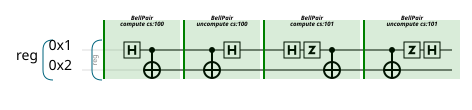

In [36]:
from psiqdk.workbench import QPU, Qubits, Qubrick

qpu = QPU(num_qubits=2)
reg = Qubits(2, "reg", qpu=qpu)

bell_pair = BellPair() # Instantiation
bell_pair_type_2 = BellPair(pair_kind=2) # Instantiation

bell_pair.compute(reg[0], reg[1])
print("After Bell Pair Type 0 Compute:")
qpu.print_state_vector()
bell_pair.uncompute()
print("After Bell Pair Type 0 Uncompute:")
qpu.print_state_vector()

print("-----------------")

bell_pair_type_2.compute(reg[0], reg[1])
print("After Bell Pair Type 2 Compute:")
qpu.print_state_vector()
bell_pair_type_2.uncompute()
print("After Bell Pair Type 2 Uncompute:")
qpu.print_state_vector()

qpu.draw(show_qubricks=True)

## Problem 10: Apply a Qubrick

**Input**:
1. An integer representing the size of the qubit register

**Goal**:

Build a quantum program that applies your GHZ Qubrick on `n` qubits. There should be `n-1` target qubits. Return the QPU.

In [ ]:
from psiqdk.workbench import QPU, Qubits, Qubrick

@problem
def apply_qubrick(n: int) -> QPU:
    qpu = QPU(num_qubits=n) # Build your QPU
    reg = Qubits(n, "reg", qpu=qpu)
    ghz = GHZ() #... # Instantiate your Qubrick
    ghz.compute(ctrl, regs) #... # Apply the Qubrick
    return qpu

Correct!
